# mBERT Model

In [46]:
! pip install "datasets==2.20.0" --quiet

In [47]:
# mBERT (Multilingual BERT) 

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay
)

In [48]:
!git clone https://github.com/vardhman18/HinSafe.git /content/HINSAFE

fatal: destination path '/content/HINSAFE' already exists and is not an empty directory.


In [49]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("/content/HINSAFE")
sys.path.insert(0, str(PROJECT_ROOT))

print("Project exists:", PROJECT_ROOT.exists())
print("src exists:", (PROJECT_ROOT / "src").exists())

Project exists: True
src exists: True


In [50]:
from src.preprocessing import basic_clean
from src.evaluate import evaluate_model

In [51]:
pd.set_option("display.max_colwidth", 100)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [52]:
# GPU check

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU device:", torch.cuda.get_device_name(0))
    DEVICE = torch.device("cuda")
else:
    print("WARNING: GPU is not available.")
    print("Enable GPU in your Colab runtime before training.")

    DEVICE = torch.device("cpu")

print("Selected device:", DEVICE)

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU device: Tesla T4
Selected device: cuda


In [53]:
# File paths

TRAIN_PATH = PROJECT_ROOT / "datasets" / "processed" / "train_split.csv"
VAL_PATH = PROJECT_ROOT / "datasets" / "processed" / "val_split.csv"
TEST_PATH = PROJECT_ROOT / "datasets" / "processed" / "test_split.csv"

MODEL_SAVE_DIR = PROJECT_ROOT / "saved_models" / "mbert"

RESULTS_PATH = PROJECT_ROOT / "results" / "model_comparison.csv"
CONFUSION_MATRIX_PATH = PROJECT_ROOT / "results" / "confusion_matrices" / "mbert.png"

MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "saved_models").mkdir(exist_ok=True)
(PROJECT_ROOT / "results" / "confusion_matrices").mkdir(parents=True, exist_ok=True)

print("Train file exists:", TRAIN_PATH.exists())
print("Validation file exists:", VAL_PATH.exists())
print("Test file exists:", TEST_PATH.exists())


Train file exists: True
Validation file exists: True
Test file exists: True


In [54]:
# Model Settings

MODEL_NAME = "google-bert/bert-base-multilingual-cased"

MAX_LENGTH = 128
BATCH_SIZE = 16
NUM_EPOCHS = 3
LEARNING_RATE = 2e-5

print("Model:", MODEL_NAME)
print("Maximum sequence length:", MAX_LENGTH)
print("Batch size:", BATCH_SIZE)
print("Epochs:", NUM_EPOCHS)
print("Learning rate:", LEARNING_RATE)

Model: google-bert/bert-base-multilingual-cased
Maximum sequence length: 128
Batch size: 16
Epochs: 3
Learning rate: 2e-05


In [55]:

# Load datasets

try:
    train_df = pd.read_csv(TRAIN_PATH)
    val_df = pd.read_csv(VAL_PATH)
    test_df = pd.read_csv(TEST_PATH)

    print("Datasets loaded successfully!\n")

    print("Training set:", train_df.shape)
    print("Validation set:", val_df.shape)
    print("Test set:", test_df.shape)

except FileNotFoundError as e:
    print("Error: Could not find one of the dataset files.")
    print("Please check the file paths.")
    print(e)

Datasets loaded successfully!

Training set: (4288, 2)
Validation set: (920, 2)
Test set: (920, 2)


In [56]:
required_columns = ["text", "label"]

for name, df in [
    ("Training", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        print(f"{name} set is missing: {missing_columns}")
    else:
        print(f"{name} set: OK")

print("\nExample training data:")
display(train_df[["text", "label"]].head())

Training set: OK
Validation set: OK
Test set: OK

Example training data:


,text,label
0,mama ke dabre se bahir a gaye ho kya baat ha chote bacha ka rape howa tha qasoor me baad me pata...,1
1,chinta kt kro beta madhur tmko tmri bhakti ke lie rajya sabha mn entry mil jaegi bo bhi rape ke ...,0
2,modi ka to pata nahi par aj vi delhi me rape ro raha hai tum log sirf modi modi modi ka mala jap...,0
3,teri gaand ka business,1
4,aur hum par terrorism ka label lagane wale duniya ache tarah jante hai aur tu bhe india is the m...,1


In [57]:
# convert pandas DataFrames to Hugging Face Datasets

train_dataset = Dataset.from_pandas(train_df[["text", "label"]])
val_dataset = Dataset.from_pandas(val_df[["text", "label"]])
test_dataset = Dataset.from_pandas(test_df[["text", "label"]])

print(train_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 4288
})


In [58]:
# Load mBERT Tokenizer

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded successfully.")
print("Tokenizer vocabulary size:", tokenizer.vocab_size)

Tokenizer loaded successfully.
Tokenizer vocabulary size: 119547


In [59]:
def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

In [60]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/4288 [00:00<?, ? examples/s]

Map:   0%|          | 0/920 [00:00<?, ? examples/s]

Map:   0%|          | 0/920 [00:00<?, ? examples/s]

In [61]:
# Keep only the columns the model needs, in PyTorch tensor format

columns_to_keep = ["input_ids", "attention_mask", "label"]

train_dataset = train_dataset.remove_columns(
    [col for col in train_dataset.column_names if col not in columns_to_keep]
)
val_dataset = val_dataset.remove_columns(
    [col for col in val_dataset.column_names if col not in columns_to_keep]
)
test_dataset = test_dataset.remove_columns(
    [col for col in test_dataset.column_names if col not in columns_to_keep]
)

In [62]:
# Inspect one tokenized example
print("Original text:", train_df["text"].iloc[0])
print("Token IDs:", train_dataset[0]["input_ids"][:20])

Original text: mama ke dabre se bahir a gaye ho kya baat ha chote bacha ka rape howa tha qasoor me baad me pata chala ke tum b un ke sath the ye ha hidmat
Token IDs: [101, 52758, 11163, 97141, 10246, 10126, 15688, 21840, 169, 29435, 10112, 13173, 87147, 10113, 15688, 10526, 10228, 11257, 10216, 15688]


In [64]:
# Load mBERT Model for Sequence Classification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2   # offensive / not offensive
)

print(f"{MODEL_NAME} loaded with a classification head")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

google-bert/bert-base-multilingual-cased loaded with a classification head


In [65]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted"),
        "precision": precision_score(labels, predictions, average="weighted"),
        "recall": recall_score(labels, predictions, average="weighted"),
    }

In [69]:
# Training Arguments

CHECKPOINT_DIR = MODEL_SAVE_DIR / "checkpoints"
TRAINING_LOG_DIR = MODEL_SAVE_DIR / "logs"

os.environ["TENSORBOARD_LOGGING_DIR"] = str(TRAINING_LOG_DIR)

training_args = TrainingArguments(
    output_dir=str(CHECKPOINT_DIR),

    # Evaluation
    eval_strategy="epoch",

    # Save checkpoint after every epoch
    save_strategy="epoch",

    # Batch sizes
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,

    # Training
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,

    # Select best checkpoint
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    # Logging
    logging_steps=50,

    # Do not automatically send data to external logging services
    report_to="none",

    # Reproducibility
    seed=42,

    # Prevent unnecessary external integrations
    push_to_hub=False
)

print("Training arguments created.")

Training arguments created.


In [70]:
# huggingface Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print("Starting training...")
trainer.train()
print("Training complete")

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.493080,0.501033,0.747826,0.731911,0.766072,0.747826
2,0.418063,0.467868,0.759783,0.747497,0.773208,0.759783
3,0.387135,0.517548,0.738043,0.735453,0.735884,0.738043


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Training complete


In [71]:
# validation evaluation

val_output = trainer.evaluate(val_dataset)
print("Validation results:")
for key, value in val_output.items():
    print(f"  {key}: {value}")

Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.387135,0.467994,3,0.761957,0.750064,0.775067,0.761957


Validation results:
  eval_loss: 0.4679936170578003
  eval_accuracy: 0.7619565217391304
  eval_f1: 0.7500638660632539
  eval_precision: 0.775066645035691
  eval_recall: 0.7619565217391304


In [75]:
# Sample predictions

def predict_single(text, model, tokenizer, max_length=MAX_LENGTH):
    """Runs one comment through the model and returns label + probability."""
    device = next(model.parameters()).device

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=max_length
    )

    inputs = {key: value.to(device) for key, value in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.softmax(outputs.logits, dim=1)[0]

    predicted_label = torch.argmax(probabilities).item()
    confidence = probabilities[predicted_label].item()

    return predicted_label, confidence



In [77]:

sample_comments = [
    "tu  mar ja",
    "thank you so much bhai",
    "kal milte hain, take care",
    "tu bekaar nahi hai"
]

cleaned_samples = [
    basic_clean(comment)
    for comment in sample_comments
]

for comment in cleaned_samples:
    label, confidence = predict_single(comment, model, tokenizer)
    label_text = "OFFENSIVE" if label == 1 else "NOT OFFENSIVE"
    print(f"{label_text:15s} | Confidence: {confidence:.4f} | {comment}")

OFFENSIVE       | Confidence: 0.9916 | tu mar ja
NOT OFFENSIVE   | Confidence: 0.9440 | thank you so much bhai
NOT OFFENSIVE   | Confidence: 0.9252 | kal milte hain take care
NOT OFFENSIVE   | Confidence: 0.8817 | tu bekaar nahi hai


In [78]:
model.save_pretrained(MODEL_SAVE_DIR)
tokenizer.save_pretrained(MODEL_SAVE_DIR)

print(f"Model and tokenizer saved to: {MODEL_SAVE_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: /content/HINSAFE/saved_models/mbert


In [81]:
# test set evaluation

test_predictions_output = trainer.predict(test_dataset)
test_logits = test_predictions_output.predictions
test_predictions = np.argmax(test_logits, axis=1)
y_test = test_df["label"].values

test_results = evaluate_model(
    y_true=y_test,
    y_pred=test_predictions,
    model_name="mBERT - Test"
)

print("Test set evaluation complete. Results:")

Test set evaluation complete. Results:


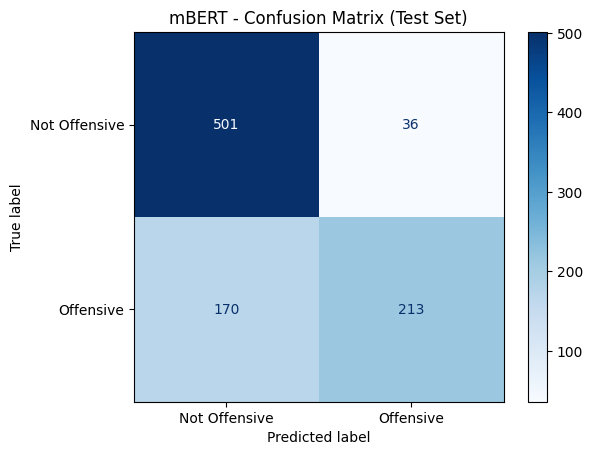

Confusion matrix saved to: /content/HINSAFE/results/confusion_matrices/mbert.png


In [83]:
cm = confusion_matrix(y_test, test_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Offensive", "Offensive"]
)

disp.plot(cmap="Blues")
plt.title("mBERT - Confusion Matrix (Test Set)")
plt.savefig(CONFUSION_MATRIX_PATH, bbox_inches="tight")
plt.show()

print(f"Confusion matrix saved to: {CONFUSION_MATRIX_PATH}")

In [ ]:
# Save mbert test results

def log_result(results_dict, results_path):
    results_row = pd.DataFrame([results_dict])

    if os.path.exists(results_path):
        existing_results = pd.read_csv(results_path)
        updated_results = pd.concat(
            [existing_results, results_row],
            ignore_index=True
        )
        
    else:
        updated_results = results_row

    # Save updated results
    updated_results.to_csv(
        results_path,
        index=False
    )
    print(f"Results saved to: {results_path}")

log_result(
    test_results,
    RESULTS_PATH
)

Results saved to: /content/HINSAFE/results/model_comparison.csv


In [85]:
if os.path.exists(RESULTS_PATH):
    results_df = pd.read_csv(RESULTS_PATH)
    display(results_df)

else:
    print("No comparison results file found.")

,model,accuracy,precision,recall,f1
0,Naive Bayes - Test,0.713043,0.856287,0.373368,0.520000
1,Logistic Regression - Test,0.751087,0.823529,0.511749,0.631240
2,Linear SVM - Test,0.744565,0.750000,0.579634,0.653903
3,Linear SVM - Test,0.744565,0.750000,0.579634,0.653903
4,Logistic Regression - Test,0.751087,0.823529,0.511749,0.631240
5,Linear SVM - Test,0.744565,0.750000,0.579634,0.653903
6,mBERT - Test,0.776087,0.855422,0.556136,0.674051
